# Sweep Voltage On Arb And Measure Noise

Qubit is moved out of the way with zero flux bias, Measuring same configuration as qubit power scans

In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime
from pathlib import Path
import os
import sys
import matplotlib.colors as mcolors
from urllib.request import urlopen

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

arb = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        arb = rm.open_resource(instrument) 
        break
print(arb.query('*IDN?').strip())
arb.write("SYSTem:LOCal")
arb.write("FUNCtion DC")
noise_source_voltage = 0.0
arb.write(f"VOLTage:OFFSet {noise_source_voltage}")
arb.write("OUTPut ON")
spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

spa_json = {}
spa_json['idn'] = spa.query('*IDN?').strip()
spa_json['fstart']    = float(spa.query(':SENS1:FREQ:START?'))
spa_json['fstop']     = float(spa.query(':SENS1:FREQ:STOP?'))
spa_json['numpoints'] = int(spa.query(':SENS1:SWEep:POINts?'))
spa_json['rbw']      = float(spa.query(':SENS:BAND?'))
spa_json['vbw'] = float(spa.query(':SENS:BAND:VID?'))
spa_json['unit'] = spa.query(":UNIT:POW?").strip()
spa.write(":SYST:LOCAL")
spa_json


Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


{'idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'fstart': 5525000000.0,
 'fstop': 5675000000.0,
 'numpoints': 101,
 'rbw': 1000000.0,
 'vbw': 1000.0,
 'unit': 'W'}

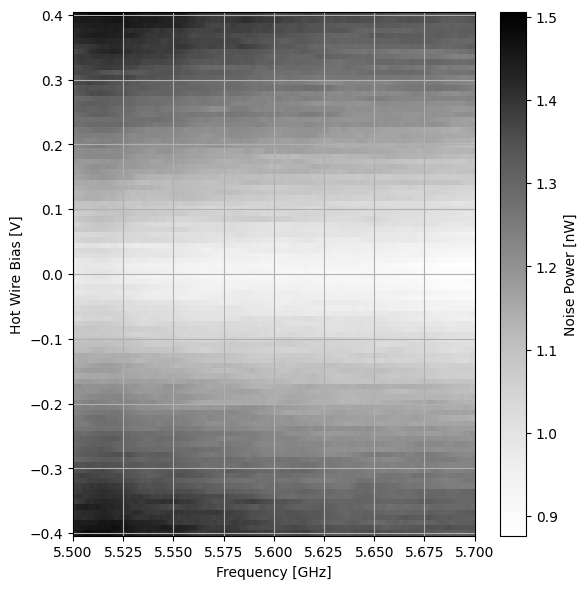

In [24]:
arb_sweep_noise = {}

arb_sweep_start = -0.4
arb_sweep_stop = 0.4
arb_sweep_number_of_points = 100

arb_sweep_noise['arb_sweep'] = np.linspace(arb_sweep_start, arb_sweep_stop, arb_sweep_number_of_points)
arb_sweep_noise['arb_sweep'] = np.round(arb_sweep_noise['arb_sweep']*10000)/10000
arb_sweep_noise['arb_sweep'] = arb_sweep_noise['arb_sweep'].tolist()


try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
arb_sweep_noise['timestamp'] = int(now.timestamp())
arb_sweep_noise['date'] = now.strftime("%d-%m-%Y")
arb_sweep_noise['time'] = now.strftime("%H:%M:%S")
arb_sweep_noise['timezone'] = now.tzname()
arb_sweep_noise['temperature'] = '0.01'
arb_sweep_noise['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + arb_sweep_noise['date'] + " Plots\n\n")

spa_json = {}
spa_json['idn'] = spa.query('*IDN?').strip()
spa_json['fstart']    = float(spa.query(':SENS1:FREQ:START?'))
spa_json['fstop']     = float(spa.query(':SENS1:FREQ:STOP?'))
spa_json['numpoints'] = int(spa.query(':SENS1:SWEep:POINts?'))
spa_json['rbw']      = float(spa.query(':SENS:BAND?'))
spa_json['vbw'] = float(spa.query(':SENS:BAND:VID?'))
spa_json['unit'] = spa.query(":UNIT:POW?").strip()
spa.write(":SYST:LOCAL")

arb_sweep_noise['spa'] = spa_json


frequencies = np.linspace(spa_json['fstart'],spa_json['fstop'],spa_json['numpoints'])
fghz = frequencies/1e9
arb_sweep_noise['fghz'] = fghz.tolist()

arb_sweep_noise['noise'] = []

for arb_voltage in arb_sweep_noise['arb_sweep']:
    arb.write(f"VOLTage:OFFSet {arb_voltage}")
    #print(arb_voltage)
    spa.write("INIT:IMM")
    spa.query("*OPC?") 
    spa_trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
    arb_sweep_noise['noise'].append(spa_trace)
    time.sleep(0.05)
spa.write("INIT:CONT ON")
spa.write(":SYST:LOCAL")
arb.write(f"VOLTage:OFFSet 0")

arb_sweep_noise['noise'] = np.array(arb_sweep_noise['noise'])
plt.figure(figsize=(6, 6))
mesh = plt.pcolormesh(
    fghz, 
    arb_sweep_noise['arb_sweep'], 
    arb_sweep_noise['noise']/1e-9, 
    shading='auto', 
    cmap='Greys'
)

#plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Hot Wire Bias [V]")

cbar = plt.colorbar(mesh)
cbar.set_label("Noise Power [nW]")

plt.tight_layout()
plt.grid()

plot_file_name = f"{arb_sweep_noise['timestamp']}-arb-sweep-scan-plot.png"
with open(readme_path, "a") as file:
    file.write("\n![]("+ plot_file_name + ")\n")

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()

scan_file_name = f"{arb_sweep_noise['timestamp']}-arb-sweep-noise.json"
file_path = target_dir / scan_file_name
arb_sweep_noise['noise'] = arb_sweep_noise['noise'].tolist()

with open(readme_path, "a") as file:
    file.write("\n### [" + scan_file_name + "]("+ scan_file_name + ")\n")

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(arb_sweep_noise, f, indent=4)